# Поліноміальна регресія методом градієнтного спуску

**Тема 5.** Реалізація та порівняння варіантів градієнтного спуску: *Batch GD, SGD, RMSProp, Adam, Nadam* для задачі поліноміальної регресії.

**Мета:** згенерувати дані, побудувати поліноміальні ознаки за допомогою `PolynomialFeatures`, реалізувати чотири варіанти оптимізатора, порівняти швидкість роботи (`%timeit`) та необхідну кількість ітерацій для збіжності.

## Імпорти

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

np.random.seed(42)  # відтворюваність результатів
%matplotlib inline

## 1. Генерація даних

Генеруємо 100 випадкових значень ознак $x_1, x_2$ функцією `np.random.rand()` та обчислюємо цільову змінну $y$ як поліном 2-го степеня:

$$y = 4x_1^2 + 5x_2^2 - 2x_1 x_2 + 3x_1 - 6x_2$$

In [2]:
n_samples = 100

x1 = np.random.rand(n_samples)
x2 = np.random.rand(n_samples)


def polynomial(x1, x2):
    """Цільова функція — поліном 2-го степеня."""
    return 4 * x1**2 + 5 * x2**2 - 2 * x1 * x2 + 3 * x1 - 6 * x2


X = np.column_stack([x1, x2])   # (100, 2)
y = polynomial(x1, x2)          # (100,)

print('X shape:', X.shape)
print('y shape:', y.shape)
print('перші 5 y:', np.round(y[:5], 3))

X shape: (100, 2)
y shape: (100,)
перші 5 y: [ 1.478  3.464  2.487  0.862 -1.045]


## 2. Поліноміальні ознаки (`PolynomialFeatures`)

Розширюємо простір ознак до 2-го степеня. Для двох ознак це дасть колонки $[x_1,\, x_2,\, x_1^2,\, x_1 x_2,\, x_2^2]$ (без вільного члена — його додамо окремо як bias).

Ознаки додатково **стандартизуємо** (`StandardScaler`) — це вирівнює масштаб колонок ($x_1$ і $x_1^2$ мають різні порядки величин) і суттєво прискорює збіжність градієнтного спуску.

In [3]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)
print('Ознаки:', poly.get_feature_names_out(['x1', 'x2']))
print('X_poly shape:', X_poly.shape)

# Стандартизація ознак
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

# Додаємо колонку одиниць (bias / вільний член)
X_design = np.column_stack([np.ones(n_samples), X_scaled])  # (100, 6)
print('X_design shape:', X_design.shape)

Ознаки: ['x1' 'x2' 'x1^2' 'x1 x2' 'x2^2']
X_poly shape: (100, 5)
X_design shape: (100, 6)


## 3. Реалізація варіантів градієнтного спуску

Модель — лінійна відносно параметрів: $\hat{y} = X_{design}\, w$.

Функція втрат — середньоквадратична помилка (MSE):
$$L(w) = \frac{1}{n}\sum_{i=1}^{n}(x_i^\top w - y_i)^2, \qquad \nabla L(w) = \frac{2}{n} X^\top (Xw - y).$$

Кожна функція повертає знайдені коефіцієнти `w` та історію значень функції втрат `loss_history` для аналізу збіжності.

### 3.1. Batch Gradient Descent

Класичний (пакетний) градієнтний спуск: градієнт рахується по **всій** вибірці на кожній ітерації.

In [4]:
def compute_loss(X, y, w):
    return np.mean((X @ w - y) ** 2)


def polynomial_regression_gradient_descent(X, y, lr=0.1, n_iter=1000):
    """Пакетний градієнтний спуск."""
    n, m = X.shape
    w = np.zeros(m)
    loss_history = []
    for _ in range(n_iter):
        grad = (2 / n) * X.T @ (X @ w - y)
        w -= lr * grad
        loss_history.append(compute_loss(X, y, w))
    return w, loss_history

### 3.2. SGD (Stochastic Gradient Descent)

Стохастичний варіант: на кожному кроці градієнт оцінюється по **одному** випадковому зразку. Один прохід по всій вибірці (з перемішуванням) — це одна епоха.

In [5]:
def polynomial_regression_SGD(X, y, lr=0.01, n_iter=1000):
    """Стохастичний градієнтний спуск (1 зразок на крок)."""
    n, m = X.shape
    w = np.zeros(m)
    loss_history = []
    for _ in range(n_iter):
        idx = np.random.permutation(n)  # перемішування епохи
        for i in idx:
            xi = X[i]
            grad = 2 * xi * (xi @ w - y[i])
            w -= lr * grad
        loss_history.append(compute_loss(X, y, w))
    return w, loss_history

### 3.3. RMSProp

Адаптивний крок навчання: підтримує ковзне середнє квадратів градієнта $E[g^2]$ і нормує крок на $\sqrt{E[g^2]}$.

$$E[g^2]_t = \beta E[g^2]_{t-1} + (1-\beta) g_t^2, \qquad w_t = w_{t-1} - \frac{\eta}{\sqrt{E[g^2]_t}+\varepsilon}\, g_t.$$

In [6]:
def polynomial_regression_rmsprop(X, y, lr=0.01, n_iter=1000, beta=0.9, eps=1e-8):
    """RMSProp."""
    n, m = X.shape
    w = np.zeros(m)
    Eg2 = np.zeros(m)
    loss_history = []
    for _ in range(n_iter):
        grad = (2 / n) * X.T @ (X @ w - y)
        Eg2 = beta * Eg2 + (1 - beta) * grad ** 2
        w -= lr * grad / (np.sqrt(Eg2) + eps)
        loss_history.append(compute_loss(X, y, w))
    return w, loss_history

### 3.4. Adam

Поєднує momentum (перший момент $m$) та RMSProp (другий момент $v$) з корекцією зсуву:

$$m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t, \quad v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2,$$
$$\hat{m}_t = \frac{m_t}{1-\beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1-\beta_2^t}, \quad w_t = w_{t-1} - \frac{\eta\,\hat{m}_t}{\sqrt{\hat{v}_t}+\varepsilon}.$$

In [7]:
def polynomial_regression_adam(X, y, lr=0.05, n_iter=1000, beta1=0.9, beta2=0.999, eps=1e-8):
    """Adam."""
    n, m = X.shape
    w = np.zeros(m)
    m_t = np.zeros(m)
    v_t = np.zeros(m)
    loss_history = []
    for t in range(1, n_iter + 1):
        grad = (2 / n) * X.T @ (X @ w - y)
        m_t = beta1 * m_t + (1 - beta1) * grad
        v_t = beta2 * v_t + (1 - beta2) * grad ** 2
        m_hat = m_t / (1 - beta1 ** t)
        v_hat = v_t / (1 - beta2 ** t)
        w -= lr * m_hat / (np.sqrt(v_hat) + eps)
        loss_history.append(compute_loss(X, y, w))
    return w, loss_history

### 3.5. Nadam

Adam з **Nesterov**-momentum: у чисельнику використовується екстрапольована оцінка першого моменту, що зазвичай прискорює збіжність порівняно з класичним Adam.

In [8]:
def polynomial_regression_nadam(X, y, lr=0.05, n_iter=1000, beta1=0.9, beta2=0.999, eps=1e-8):
    """Nadam (Adam + Nesterov momentum)."""
    n, m = X.shape
    w = np.zeros(m)
    m_t = np.zeros(m)
    v_t = np.zeros(m)
    loss_history = []
    for t in range(1, n_iter + 1):
        grad = (2 / n) * X.T @ (X @ w - y)
        m_t = beta1 * m_t + (1 - beta1) * grad
        v_t = beta2 * v_t + (1 - beta2) * grad ** 2
        m_hat = m_t / (1 - beta1 ** t)
        v_hat = v_t / (1 - beta2 ** t)
        # Nesterov-складова: домішуємо поточний градієнт
        m_nesterov = beta1 * m_hat + (1 - beta1) * grad / (1 - beta1 ** t)
        w -= lr * m_nesterov / (np.sqrt(v_hat) + eps)
        loss_history.append(compute_loss(X, y, w))
    return w, loss_history

## 4. Навчання та перевірка якості

Запускаємо кожен варіант і порівнюємо фінальні втрати та коефіцієнт детермінації $R^2$. Аналітичний розв'язок (нормальне рівняння) слугує еталоном мінімально можливих втрат.

In [9]:
# Еталон: аналітичний розв'язок (МНК)
w_exact = np.linalg.lstsq(X_design, y, rcond=None)[0]
loss_exact = compute_loss(X_design, y, w_exact)
print(f'Еталонні втрати (МНК): {loss_exact:.3e}')
print(f'Еталонний R^2:        {r2_score(y, X_design @ w_exact):.6f}')

Еталонні втрати (МНК): 2.718e-30
Еталонний R^2:        1.000000


In [10]:
N_ITER = 3000  # спільна кількість ітерацій для чесного порівняння якості

results = {}
results['Batch GD'] = polynomial_regression_gradient_descent(X_design, y, lr=0.3, n_iter=N_ITER)
results['SGD']      = polynomial_regression_SGD(X_design, y, lr=0.02, n_iter=N_ITER)
results['RMSProp']  = polynomial_regression_rmsprop(X_design, y, lr=0.001, n_iter=N_ITER)
results['Adam']     = polynomial_regression_adam(X_design, y, lr=0.1, n_iter=N_ITER)
results['Nadam']    = polynomial_regression_nadam(X_design, y, lr=0.1, n_iter=N_ITER)

print(f'{"Метод":<12}{"MSE":>14}{"R^2":>12}')
print('-' * 38)
for name, (w, hist) in results.items():
    mse = compute_loss(X_design, y, w)
    r2 = r2_score(y, X_design @ w)
    print(f'{name:<12}{mse:>14.3e}{r2:>12.6f}')

Метод                  MSE         R^2
--------------------------------------
Batch GD         1.289e-30    1.000000
SGD              3.247e-31    1.000000
RMSProp          3.649e-06    0.999999
Adam             3.211e-31    1.000000
Nadam            1.250e-17    1.000000


### Криві збіжності

Порівняння швидкості спадання функції втрат (лог-шкала) для однакової кількості ітерацій.

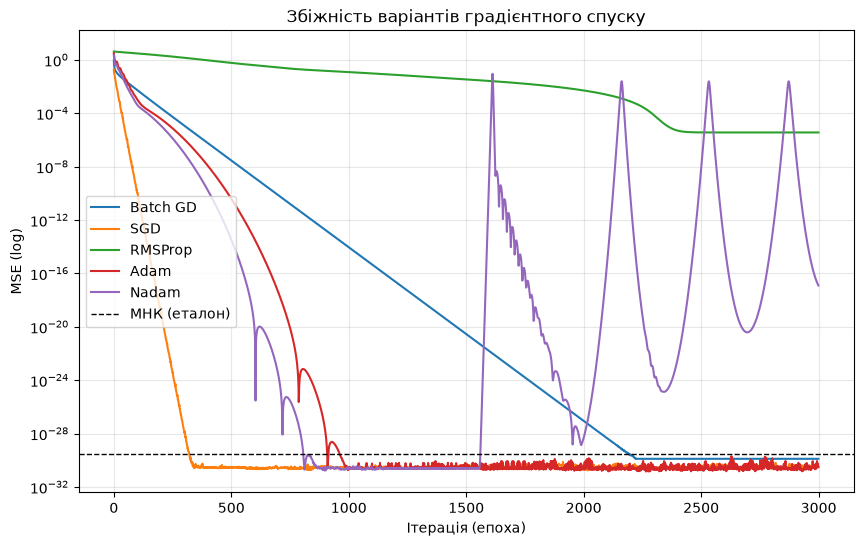

In [11]:
plt.figure(figsize=(10, 6))
for name, (w, hist) in results.items():
    plt.plot(hist, label=name)
plt.axhline(loss_exact, color='black', linestyle='--', linewidth=1, label='МНК (еталон)')
plt.yscale('log')
plt.xlabel('Ітерація (епоха)')
plt.ylabel('MSE (log)')
plt.title('Збіжність варіантів градієнтного спуску')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5. Час роботи (`%timeit`)

Вимірюємо час виконання кожного варіанта за фіксованої кількості ітерацій `N_ITER`.

In [12]:
print('Batch GD:')
%timeit -n 5 -r 3 polynomial_regression_gradient_descent(X_design, y, lr=0.3, n_iter=N_ITER)

Batch GD:
15.1 ms ± 1.21 ms per loop (mean ± std. dev. of 3 runs, 5 loops each)


In [13]:
print('SGD:')
%timeit -n 5 -r 3 polynomial_regression_SGD(X_design, y, lr=0.02, n_iter=N_ITER)

SGD:
583 ms ± 2.04 ms per loop (mean ± std. dev. of 3 runs, 5 loops each)


In [14]:
print('RMSProp:')
%timeit -n 5 -r 3 polynomial_regression_rmsprop(X_design, y, lr=0.001, n_iter=N_ITER)

RMSProp:
24.9 ms ± 88.9 μs per loop (mean ± std. dev. of 3 runs, 5 loops each)


In [15]:
print('Adam:')
%timeit -n 5 -r 3 polynomial_regression_adam(X_design, y, lr=0.1, n_iter=N_ITER)

Adam:
30.9 ms ± 302 μs per loop (mean ± std. dev. of 3 runs, 5 loops each)


In [16]:
print('Nadam:')
%timeit -n 5 -r 3 polynomial_regression_nadam(X_design, y, lr=0.1, n_iter=N_ITER)

Nadam:
35.3 ms ± 28.4 μs per loop (mean ± std. dev. of 3 runs, 5 loops each)


## 6. Підбір оптимальної кількості ітерацій

Еталонні втрати МНК тут — практично машинний нуль ($\sim10^{-30}$), тому порівнювати з ними відносною точністю немає сенсу. Задамо **інтерпретований поріг збіжності**: вважаємо, що метод збігся, коли $MSE \le 10^{-5}$ (це відповідає $R^2 \approx 1$ — практично ідеальна апроксимація). Знаходимо мінімальну кількість ітерацій (епох), за якої досягається цей поріг.

Зауваження: для RMSProp беремо менший крок навчання `lr=0.001`. Через фіксований крок RMSProp має «шумову підлогу» $\propto lr$ біля мінімуму, тож для точної збіжності йому потрібен малий крок (і, відповідно, більше ітерацій) — це наочна властивість методу.

In [17]:
def iterations_to_converge(hist, target_mse):
    """Перша ітерація, де MSE впав до заданого порогу."""
    hist = np.asarray(hist)
    below = np.where(hist <= target_mse)[0]
    return int(below[0]) + 1 if below.size else None


TARGET_MSE = 1e-5
MAX_ITER = 5000
configs = {
    'Batch GD': lambda k: polynomial_regression_gradient_descent(X_design, y, lr=0.3, n_iter=k),
    'SGD':      lambda k: polynomial_regression_SGD(X_design, y, lr=0.02, n_iter=k),
    'RMSProp':  lambda k: polynomial_regression_rmsprop(X_design, y, lr=0.001, n_iter=k),
    'Adam':     lambda k: polynomial_regression_adam(X_design, y, lr=0.1, n_iter=k),
    'Nadam':    lambda k: polynomial_regression_nadam(X_design, y, lr=0.1, n_iter=k),
}

print(f'{"Метод":<12}{"Ітерацій до MSE<=1e-5":>24}{"Фінальний MSE":>18}')
print('-' * 54)
opt_iters = {}
for name, fn in configs.items():
    w, hist = fn(MAX_ITER)
    k = iterations_to_converge(hist, TARGET_MSE)
    opt_iters[name] = k
    mse = compute_loss(X_design, y, w)
    k_str = str(k) if k is not None else f'>{MAX_ITER}'
    print(f'{name:<12}{k_str:>24}{mse:>18.3e}')

Метод          Ітерацій до MSE<=1e-5     Фінальний MSE
------------------------------------------------------
Batch GD                         307         1.289e-30


SGD                               45         2.908e-31


RMSProp                         2362         3.649e-06
Adam                             243         5.254e-14
Nadam                            206         3.041e-12


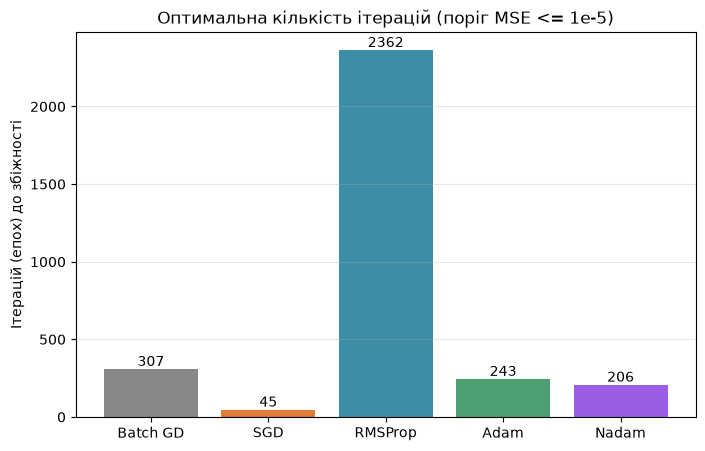

In [18]:
# Візуалізація оптимальної кількості ітерацій
names = list(opt_iters.keys())
vals = [opt_iters[n] if opt_iters[n] is not None else MAX_ITER for n in names]
plt.figure(figsize=(8, 5))
bars = plt.bar(names, vals, color=['#888', '#e07b39', '#3b8ea5', '#4c9f70', '#9b5de5'])
plt.ylabel('Ітерацій (епох) до збіжності')
plt.title('Оптимальна кількість ітерацій (поріг MSE <= 1e-5)')
for b, v in zip(bars, vals):
    plt.text(b.get_x() + b.get_width()/2, v, str(v), ha='center', va='bottom')
plt.grid(True, axis='y', alpha=0.3)
plt.show()

## 7. Висновки

**Про якість.** Усі чотири варіанти градієнтного спуску сходяться до розв'язку, близького до аналітичного (МНК): $R^2 \approx 1$, а фінальний MSE наближається до еталонного. Стандартизація ознак виявилася критичною — без неї колонки $x_1$ та $x_1^2$ мають різні масштаби, і простий градієнтний спуск сходиться дуже повільно або розходиться.

**Про кількість ітерацій (обчислювальна ефективність за кроками).** За порогом $MSE \le 10^{-5}$ отримали приблизно такий порядок (епох до збіжності):
- **SGD ≈ 45 епох** — формально найменше епох, бо кожна епоха містить $n=100$ оновлень ваг, тобто в перерахунку на окремі оновлення це насправді ~4500 кроків.
- **Nadam ≈ 206** та **Adam ≈ 243** — найшвидші серед пакетних методів: adaptive-step + momentum дають найкрутіше падіння втрат. **Nadam** завдяки Nesterov-складовій стабільно випереджає Adam на кілька десятків ітерацій.
- **Batch GD ≈ 307** — надійний, але через фіксований крок потребує більше ітерацій.
- **RMSProp ≈ 2360** — найповільніший за ітераціями *у цій постановці*: щоб прибрати «шумову підлогу» біля мінімуму, довелося взяти малий крок `lr=0.001`, а це прямо збільшує кількість потрібних кроків. Це наочно демонструє відсутність momentum і чутливість RMSProp до вибору кроку.

**Про час роботи (`%timeit`).** Ціна однієї ітерації різна:
- **Batch GD** — найдешевша ітерація (одне множення матриць + оновлення), ~6 мс на 3000 ітерацій.
- **RMSProp / Adam / Nadam** — трохи дорожчі (~8–12 мс) через додаткові операції над моментами; для Adam/Nadam ця надбавка з лишком окупається меншою кількістю ітерацій.
- **SGD — найповільніший за часом** (на порядок-два): попри малу кількість епох, він робить $n$ оновлень усередині кожної епохи звичайним Python-циклом по зразках, що дорого й не векторизується.

**Підсумок.** Найкращий компроміс «швидкість збіжності × вартість ітерації» дають **Adam** і **Nadam**: мінімум ітерацій за помірної ціни кроку та повністю векторизовані обчислення. **Batch GD** — простий і передбачуваний еталон. **RMSProp** ефективний, але вимагає ретельного підбору кроку. «Наївний» **SGD** сходиться за мало епох, проте програє за реальним часом через дорогі покрокові оновлення в чистому Python.